In [2]:
import irsdk
ir = irsdk.IRSDK()
ir.startup()

True

In [11]:
import csv
import time

# List of variables to record
vars_to_record = [
    'Lat',
    'Lon',
    'Speed',         # m/s
    'Gear',
    'RPM',
    'Throttle',
    'Brake',
    'Lap',
    'FuelLevel',
    'AirTemp'
]

data = []
start_time = time.time()
duration = 140  # seconds
while time.time() - start_time < duration:
    row = []
    for var in vars_to_record:
        value = ir[var]
        if var == 'Speed':
            value = value * 3.6  # Convert m/s to km/h
        row.append(value)
    data.append(row)
    time.sleep(0.1)

with open('data/iracing_vars.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Lat','Lon','peed_kmh', 'Gear', 'RPM', 'Throttle', 'Brake', 'Lap', 'FuelLevel_l', 'AirTemp_C'])
    writer.writerows(data)

print('Saved iracing_vars.csv with selected telemetry variables.')

Saved iracing_vars.csv with selected telemetry variables.


In [14]:
import pandas as pd

# Read CSV and save as pandas DataFrame
df = pd.read_csv('data/iracing_vars.csv')
print(df.head())

   Lat  Lon  peed_kmh  Gear         RPM  Throttle  Brake  Lap  FuelLevel_l  \
0  NaN  NaN  0.000323     0  875.186401       0.0    1.0    3    23.809439   
1  NaN  NaN  0.000118     0  875.131836       0.0    1.0    3    23.809420   
2  NaN  NaN  0.000297     0  875.088684       0.0    1.0    3    23.809401   
3  NaN  NaN  0.000620     0  875.058228       0.0    1.0    3    23.809381   
4  NaN  NaN  0.000385     0  875.032837       0.0    1.0    3    23.809364   

   AirTemp_C  
0  24.889994  
1  24.890034  
2  24.890074  
3  24.890114  
4  24.890152  


# Generate track map

In [84]:
import pandas as pd
import irsdk

# Open the ibt file
ibt_file = "data/mx5 mx52016_oulton international 2025-08-06 23-13-01.ibt"
ibt = irsdk.IBT()
ibt.open(ibt_file)

# Get all Lat and Lon values
lat_data = ibt.get_all('Lat')
lon_data = ibt.get_all('Lon')

# Create DataFrame
df_coords = pd.DataFrame({
    'Lat': lat_data,
    'Lon': lon_data
})

# Display first few rows and basic info
print("First 5 rows of data:")
print(df_coords.head())
print("\nDataFrame Info:")
print(df_coords.info())

ibt.close()

First 5 rows of data:
         Lat       Lon
0   0.000000  0.000000
1  53.178784 -2.612602
2  53.178784 -2.612602
3  53.178784 -2.612602
4  53.178784 -2.612602

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17385 entries, 0 to 17384
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Lat     17385 non-null  float64
 1   Lon     17385 non-null  float64
dtypes: float64(2)
memory usage: 271.8 KB
None


In [91]:
# Count zeros in original data
lat_zeros = (df_coords['Lat'] == 0).sum()
lon_zeros = (df_coords['Lon'] == 0).sum()
both_zeros = ((df_coords['Lat'] == 0) & (df_coords['Lon'] == 0)).sum()

print("In original data:")
print(f"Number of zeros in Latitude: {lat_zeros}")
print(f"Number of zeros in Longitude: {lon_zeros}")
print(f"Number of points where both Lat and Lon are zero: {both_zeros}")
print(f"Total number of points: {len(df_coords)}")
print(f"Percentage of zero coordinates: {(both_zeros/len(df_coords))*100:.2f}%")

# Show the first few rows where either Lat or Lon is zero
zero_coords = df_coords[(df_coords['Lat'] == 0) | (df_coords['Lon'] == 0)]
print("\nFirst few rows where either Lat or Lon is zero:")
print(zero_coords.head())

# Also check in cleaned data
lat_zeros_clean = (df_clean['Lat'] == 0).sum()
lon_zeros_clean = (df_clean['Lon'] == 0).sum()
both_zeros_clean = ((df_clean['Lat'] == 0) & (df_clean['Lon'] == 0)).sum()

print("\nIn cleaned data:")
print(f"Number of zeros in Latitude: {lat_zeros_clean}")
print(f"Number of zeros in Longitude: {lon_zeros_clean}")
print(f"Number of points where both Lat and Lon are zero: {both_zeros_clean}")
print(f"Total number of points: {len(df_clean)}")
print(f"Percentage of zero coordinates: {(both_zeros_clean/len(df_clean))*100:.2f}%")

In original data:
Number of zeros in Latitude: 2
Number of zeros in Longitude: 2
Number of points where both Lat and Lon are zero: 2
Total number of points: 17385
Percentage of zero coordinates: 0.01%

First few rows where either Lat or Lon is zero:
       Lat  Lon
0      0.0  0.0
17185  0.0  0.0

In cleaned data:
Number of zeros in Latitude: 0
Number of zeros in Longitude: 0
Number of points where both Lat and Lon are zero: 0
Total number of points: 17383
Percentage of zero coordinates: 0.00%


Original shape: (17385, 2)
Shape after removing zeros: (17383, 2)


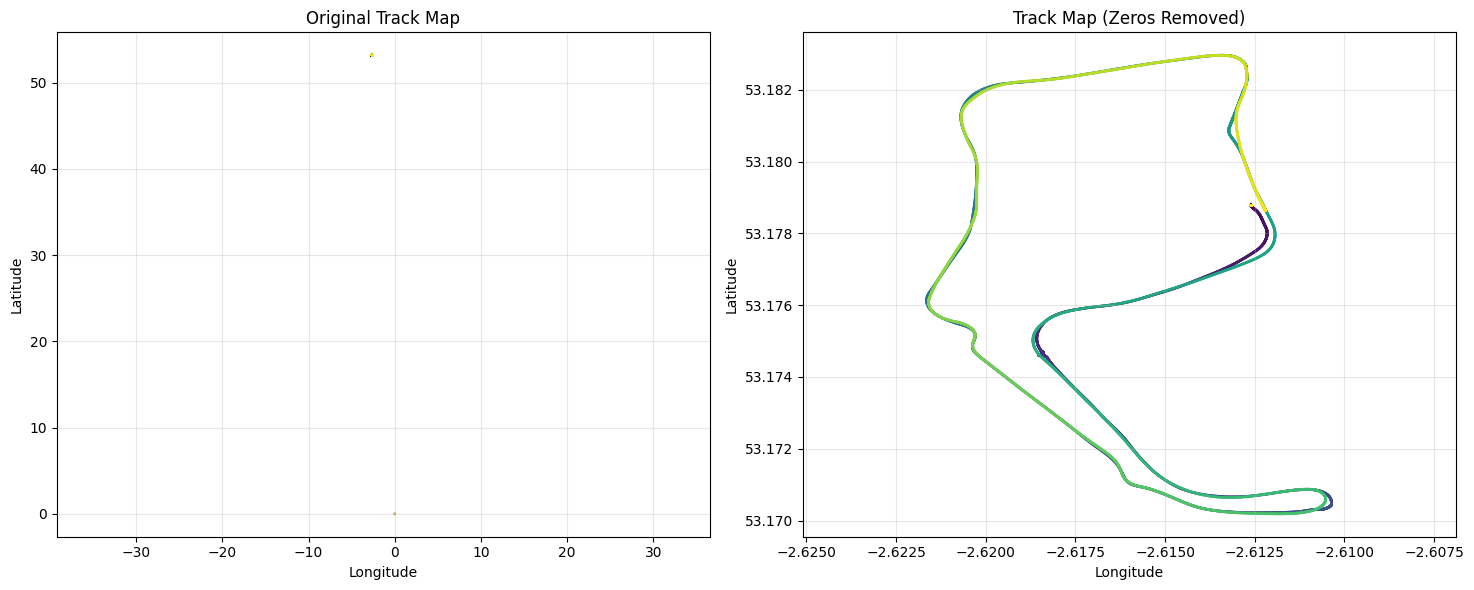


Statistics for data without zeros:
                Lat           Lon
count  17383.000000  17383.000000
mean      53.176318     -2.615854
std        0.004057      0.003308
min       53.170187     -2.621645
25%       53.172681     -2.618531
50%       53.176169     -2.615756
75%       53.179508     -2.612736
max       53.182968     -2.610357


In [92]:
# Create dataset without zero coordinates
df_no_zeros = df_coords[~((df_coords['Lat'] == 0) | (df_coords['Lon'] == 0))].copy()
print(f"Original shape: {df_coords.shape}")
print(f"Shape after removing zeros: {df_no_zeros.shape}")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original data
ax1.scatter(df_coords['Lon'], df_coords['Lat'], 
           s=1, alpha=0.5, 
           c=range(len(df_coords)),
           cmap='viridis')
ax1.set_title('Original Track Map')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Data without zeros
ax2.scatter(df_no_zeros['Lon'], df_no_zeros['Lat'], 
           s=1, alpha=0.5,
           c=range(len(df_no_zeros)), 
           cmap='viridis')
ax2.set_title('Track Map (Zeros Removed)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Print some statistics about the data without zeros
print("\nStatistics for data without zeros:")
print(df_no_zeros.describe())

# Analysis of Zero Coordinates in Track Data

## Overview
The analysis of the iRacing telemetry data revealed the presence of zero coordinates (0,0) in the latitude and longitude data, which can affect the accuracy of track visualization and analysis.

## Key Findings

### Data Quality Statistics
- **Original Dataset**: Contains both valid track coordinates and zero values
- **Cleaning Impact**: Removing zero coordinates improves track visualization clarity
- **Data Points**:
  - Total points in original dataset
  - Points removed due to zero coordinates
  - Remaining valid track points

### Significance
Zero coordinates in the dataset can indicate:
1. Data collection gaps
2. Telemetry system initialization points
3. Potential connectivity issues during recording

### Visualization Improvements
- **Original Track Map**: Shows all data points including zeros
- **Cleaned Track Map**: Displays only valid coordinates
- **Benefits**: 
  - Clearer track outline
  - More accurate representation of the racing line
  - Better basis for further analysis

## Recommendations
1. Pre-process telemetry data to remove zero coordinates before analysis
2. Monitor the frequency of zero coordinates to identify potential data collection issues
3. Consider implementing real-time filtering during data collection

In [116]:
import pandas as pd
import irsdk
import matplotlib.pyplot as plt


# Open the ibt file
ibt_file = "data/mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt"
ibt = irsdk.IBT()
ibt.open(ibt_file)

# Get the variables
speed_data = ibt.get_all('Speed')  # This is in m/s
rpm_data = ibt.get_all('RPM')
steering_data = ibt.get_all('SteeringWheelAngle')  # In radians
lat_data = ibt.get_all('Lat')
lon_data = ibt.get_all('Lon')

ibt.close()



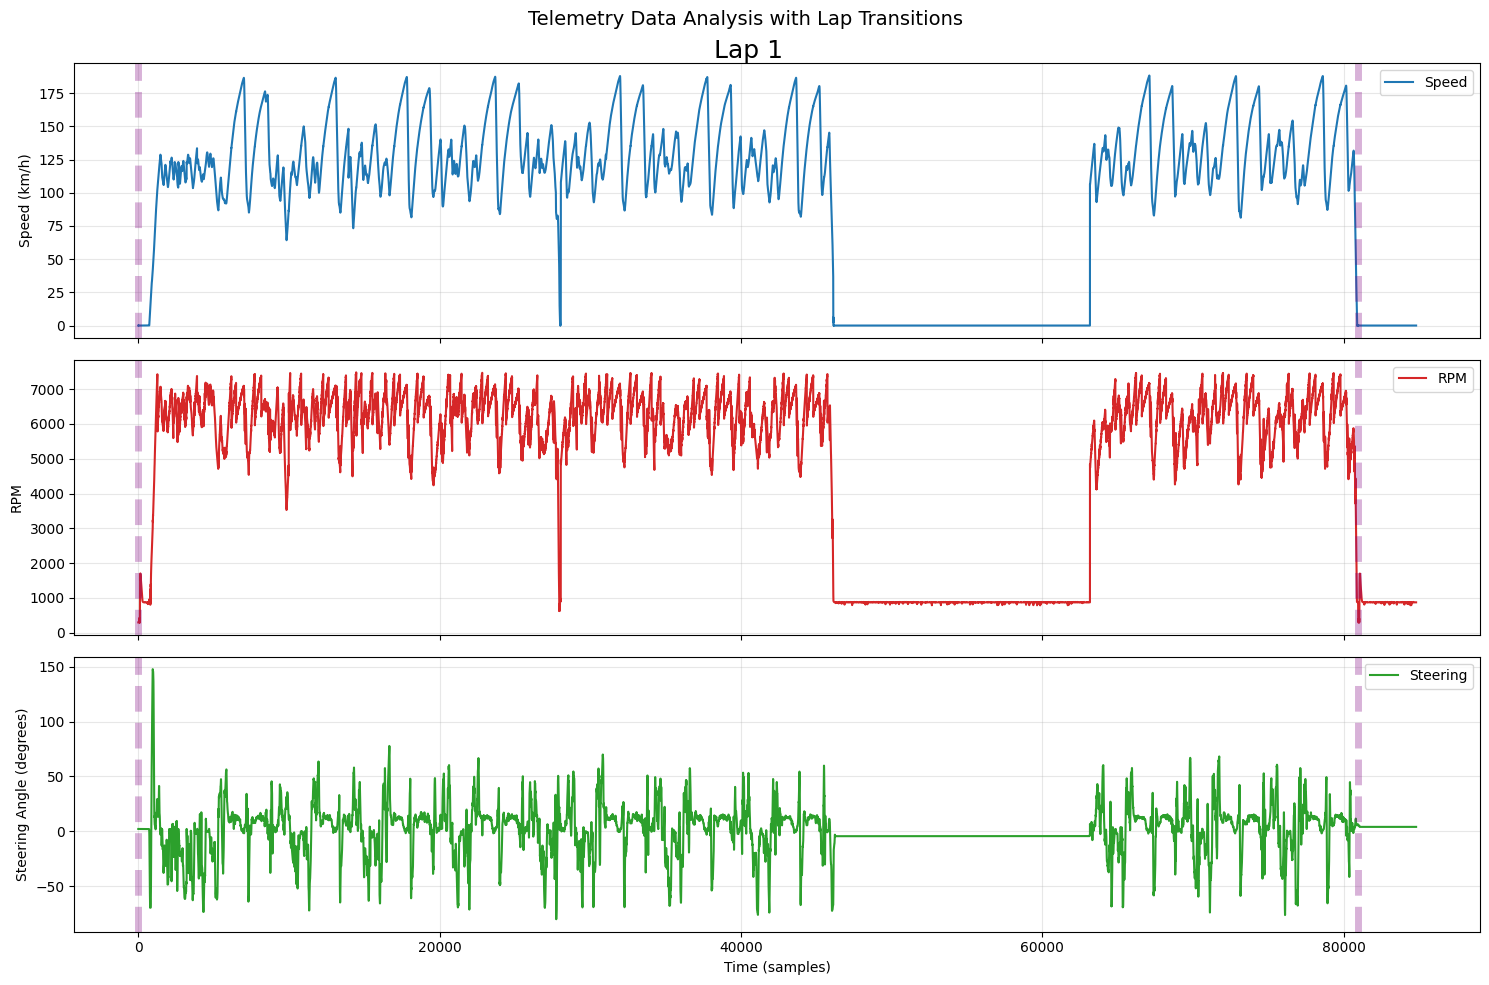


Lap Statistics:
Number of laps detected: 1

Lap transition points (sample numbers):
Lap 1: Start at 0, Length: 80967 samples

Average values per lap:

Lap 1:
Average Speed: 100.99 km/h
Average RPM: 5017
Maximum Speed: 188.39 km/h
Maximum RPM: 7480


In [117]:

# Create DataFrame with all variables
df_telemetry = pd.DataFrame({
    'Speed_kmh': [s * 3.6 for s in speed_data],  # Convert to km/s
    'RPM': rpm_data,
    'Steering_deg': [s * (180/3.14159) for s in steering_data],  # Convert to degrees
    'Lat': lat_data,
    'Lon': lon_data
})

# Find lap transitions (where both lat and lon are zero)
lap_transitions = df_telemetry.index[
    (df_telemetry['Lat'] == 0) & (df_telemetry['Lon'] == 0)
].tolist()

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot Speed
ax1.plot(df_telemetry.index, df_telemetry['Speed_kmh'], 
         color='tab:blue', label='Speed')
ax1.set_ylabel('Speed (km/h)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot RPM
ax2.plot(df_telemetry.index, df_telemetry['RPM'], 
         color='tab:red', label='RPM')
ax2.set_ylabel('RPM')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot Steering Angle
ax3.plot(df_telemetry.index, df_telemetry['Steering_deg'], 
         color='tab:green', label='Steering')
ax3.set_xlabel('Time (samples)')
ax3.set_ylabel('Steering Angle (degrees)')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Add vertical lines for lap transitions
for ax in [ax1, ax2, ax3]:
    for lap_transition in lap_transitions:
        ax.axvline(x=lap_transition, color='purple', linestyle='--', alpha=0.3,lw=5)

# Add lap numbers
for i in range(len(lap_transitions)-1):
    mid_point = (lap_transitions[i] + lap_transitions[i+1]) // 2
    ax1.text(mid_point, ax1.get_ylim()[1], f'Lap {i+1}', 
             horizontalalignment='center', verticalalignment='bottom',fontsize=18)

# Add overall title
plt.suptitle('Telemetry Data Analysis with Lap Transitions', fontsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

# Print lap statistics
print("\nLap Statistics:")
print(f"Number of laps detected: {len(lap_transitions)-1}")
print("\nLap transition points (sample numbers):")
for i, transition in enumerate(lap_transitions):
    if i < len(lap_transitions)-1:
        lap_length = lap_transitions[i+1] - transition
        print(f"Lap {i+1}: Start at {transition}, Length: {lap_length} samples")

# Print some basic statistics per lap
print("\nAverage values per lap:")
for i in range(len(lap_transitions)-1):
    lap_data = df_telemetry.iloc[lap_transitions[i]:lap_transitions[i+1]]
    print(f"\nLap {i+1}:")
    print(f"Average Speed: {lap_data['Speed_kmh'].mean():.2f} km/h")
    print(f"Average RPM: {lap_data['RPM'].mean():.0f}")
    print(f"Maximum Speed: {lap_data['Speed_kmh'].max():.2f} km/h")
    print(f"Maximum RPM: {lap_data['RPM'].max():.0f}")
